##Project Setup & Data Loading

In [1]:
## Import libraries and configure pandas display settings for better data visibility

import pandas as pd
import numpy as np

# display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

##This block prepares your analysis environment so you can clearly see and understand every column in your churn dataset.

In [2]:
import os
os.getcwd()

##This code tells you where Python is currently looking for files, which is crucial before loading your churn dataset.

'C:\\Users\\Aryan Singh Rajput\\Churn-Recommendation-Project'

In [3]:
os.listdir()

##This line shows all files in your current working directory so you can confirm your churn dataset is present before loading it.

['.ipynb_checkpoints', '01_EDA.ipynb', 'Data', 'models', 'Notebook']

In [4]:
df = pd.read_csv("Data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

##This line loads your Telco churn CSV file into a pandas DataFrame so you can start analysis and machine learning.

In [5]:
#import os
#os.path.exists("../Data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
#The above path is not working earlier when we directly copy paste the path from data folder becouse of hierarchial structure of folders we are using now the current path first exits from notebook to churn recommendation project folder and then search in to data folder for text csv


In [6]:
# shape of dataset
print("Dataset Shape:", df.shape)

# column names
print("\nColumns:\n", df.columns)

# data types and nulls
df.info()

##This block inspects the dataset’s size, columns, data types, and missing values to prepare for proper preprocessing and modeling.

Dataset Shape: (7043, 21)

Columns:
 Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   

In [7]:
# check missing values
df.isnull().sum()

##This line counts missing values in each column so we know which features require cleaning before modeling.


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
# churn distribution
df['Churn'].value_counts()

##This line shows how many customers churned vs stayed, helping us detect class imbalance and plan proper modeling strategies.

Churn
No     5174
Yes    1869
Name: count, dtype: int64

#Data Cleaning

In [9]:
# drop customerID
df.drop(columns=['customerID'], inplace=True)

df.head()

##This step removes a non-predictive customer identifier and verifies the dataset structure before further preprocessing.

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
# convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# check missing values again
df.isnull().sum()

##This step converts TotalCharges into a numeric feature and safely handles invalid values by converting them into missing values for proper preprocessing.

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [11]:
#Handling Missing Values
df['TotalCharges'].fillna(0, inplace=True)

##This step replaces missing TotalCharges values with zero, which is logically correct for new customers and ensures the dataset is ready for machine learning models.

C:\Users\Aryan Singh Rajput\AppData\Local\Temp\ipykernel_15300\819609022.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


In [12]:
#Convert target variable churn yes-1 & no-0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

df['Churn'].value_counts()

##This step converts the churn target into numeric form (1 = churn, 0 = non-churn) so it can be used by machine learning models.

Churn
0    5174
1    1869
Name: count, dtype: int64

In [13]:
##we are removing  gender and seniorcitizen beacause gender values are not in yes and no  and we #are going to encode for yes and no categorical columns only and second seniorcitizen are #already in 0&1 binary form so we again dont want to map encodingto thme
binary_cols = [col for col in df.columns if df[col].nunique() == 2 and col != 'Churn' and col != "gender" and col != "SeniorCitizen"]
binary_cols

##This code dynamically selects all Yes/No binary feature columns while excluding the target, gender, and already-encoded variables to prepare for proper binary encoding.

['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

In [14]:
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

    ##This loop converts all selected Yes/No categorical features into numeric binary values so they can be used by machine learning models.


In [15]:
df.head()

##This command previews the dataset to verify that all preprocessing steps were applied correctly before moving forward.

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,Male,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,Male,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,Male,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [16]:
#binary_cols = [col for col in df.columns if df[col].nunique() == 2 and col != 'Churn']
#binary_cols

##This commented code represents an earlier, less strict binary-feature selection logic that was intentionally abandoned to avoid incorrect encoding of gender and already-numeric features.

In [17]:
#Incoding service column 
service_cols = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

for col in service_cols:
    df[col] = df[col].replace({
        'Yes': 1,
        'No': 0,
        'No internet service': 0
    })

    ##This step encodes internet service–related features by converting service presence to binary form while logically treating “No internet service” as absence of the service.

C:\Users\Aryan Singh Rajput\AppData\Local\Temp\ipykernel_15300\45028970.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({


In [18]:
df.head()

##This command verifies that service-related categorical features have been successfully encoded and the dataset remains clean before further preprocessing.

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,1,0,1,0,No phone service,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,Male,0,0,0,34,1,No,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,Male,0,0,0,2,1,No,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,Male,0,0,0,45,0,No phone service,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,0,0,2,1,No,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


In [19]:
# Encode gender column: Male → 1, Female → 0

df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

df['gender'].value_counts()

##This step converts the gender feature into numeric binary form and verifies the distribution to ensure correct encoding.

gender
1    3555
0    3488
Name: count, dtype: int64

In [20]:
df.head()

##This command verifies that all recent feature encodings were applied correctly before moving to the final preprocessing steps.

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,No,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


In [21]:
# check data types
df.dtypes

##This command shows the data type of each column so we can confirm which features are numeric and which still require encoding before model training.

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines        object
InternetService      object
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract             object
PaperlessBilling      int64
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

In [22]:
# create cleaned data directory if not exists
import os

os.makedirs("../data/processed", exist_ok=True)

# save cleaned dataset
df.to_csv("../data/processed/telco_churn_cleaned.csv", index=False)

print("✅ Cleaned dataset saved successfully")

##This block creates a processed-data directory and saves the fully cleaned churn dataset so it can be reused directly for model training.

✅ Cleaned dataset saved successfully


##EDA

In [23]:
## Import required libraries, set visualization style, and load the cleaned churn dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# visualization style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

# load cleaned data
df = pd.read_csv("../data/processed/telco_churn_cleaned.csv")

##This block sets up data analysis and visualization libraries, configures plotting styles, and loads the finalized churn dataset for modeling and insights.

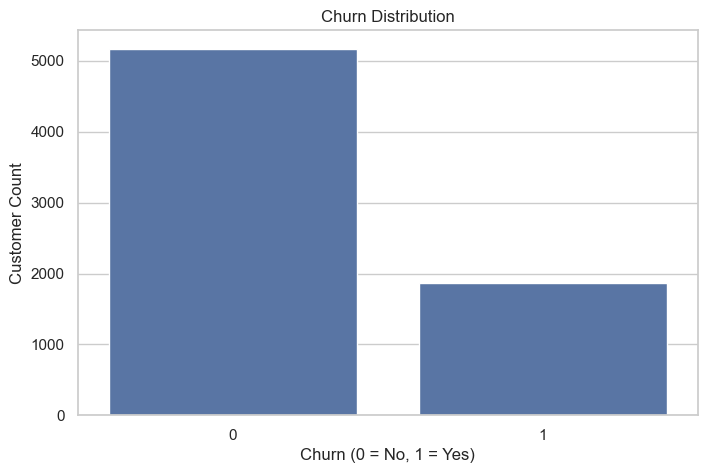

Churn
0    5174
1    1869
Name: count, dtype: int64

In [24]:
## Analyzing and visualizing the distribution of the churn target variable

churn_counts = df['Churn'].value_counts()

sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Customer Count")
plt.show()

churn_counts

#non churn customers are more than churn customers , Dataset is imblanced but not extreamly
##This analysis visualizes and quantifies the churn target distribution, revealing a moderate class imbalance that requires careful metric selection during model evaluation.


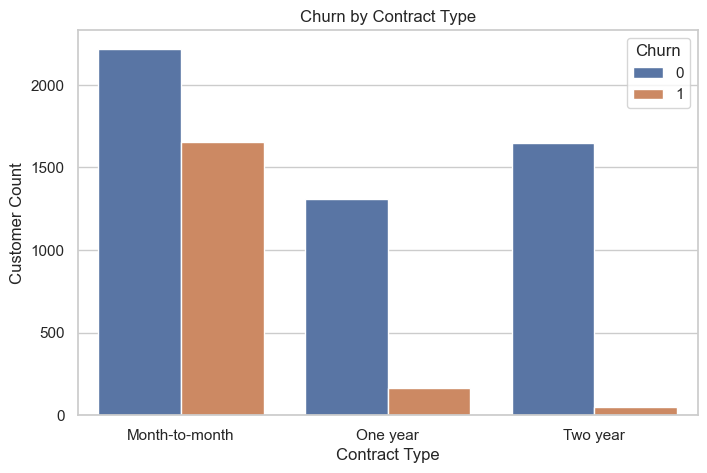

In [25]:
## Visualizing churn distribution across different contract types

sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Customer Count")
plt.legend(title="Churn")
plt.show()

#How contract duration affect churn , Month to month customer churn most and 2 year customers churn least 
##This visualization shows that churn is significantly higher among month-to-month customers and lowest among two-year contract customers, indicating contract duration strongly influences churn behavior.


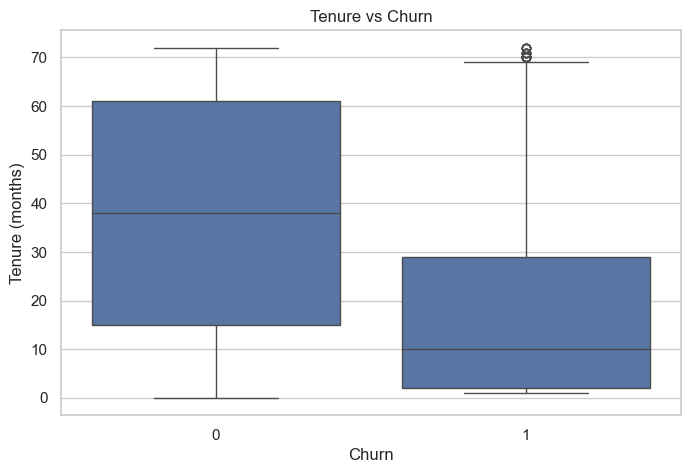

In [26]:
## Visualizing the relationship between customer tenure and churn status

sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (months)")
plt.show()

##The boxplot shows that customers who churn generally have significantly lower tenure, indicating that newer customers are more likely to leave.


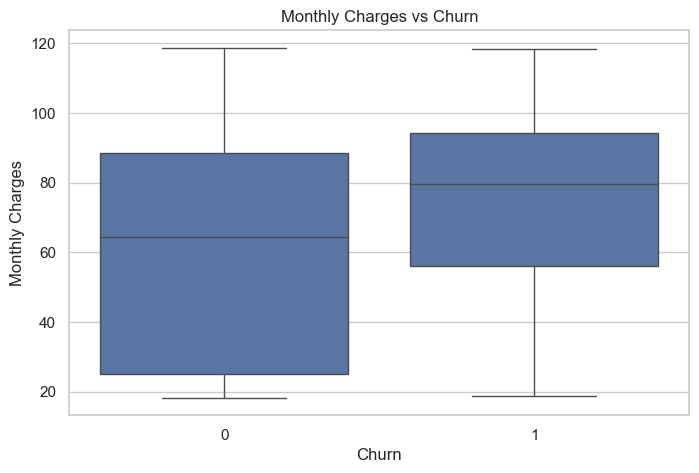

In [27]:
# churn vs Monthly charges 
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

##Customers with higher monthly charges show a greater tendency to churn, suggesting that pricing or perceived value may influence customer retention.

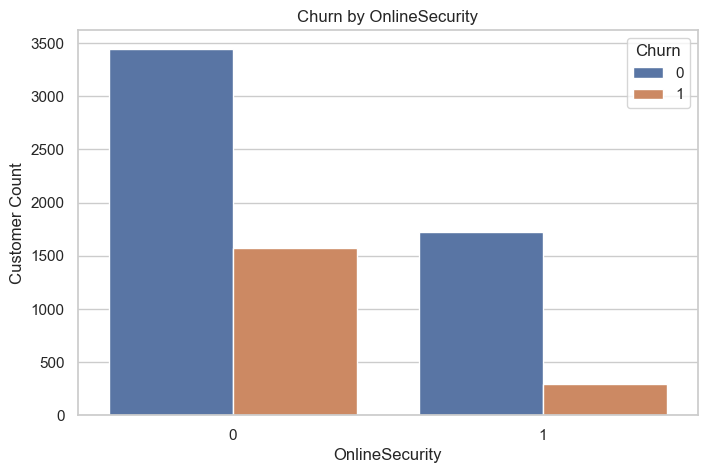

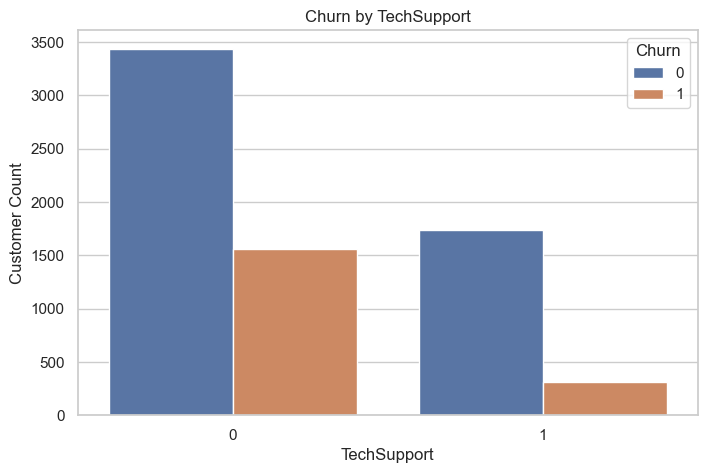

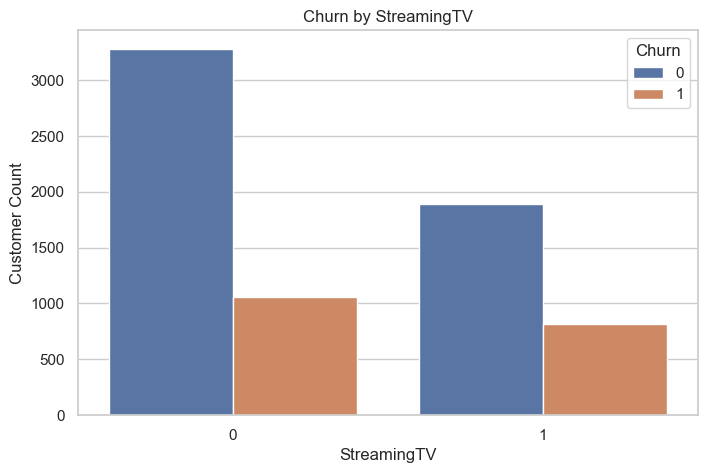

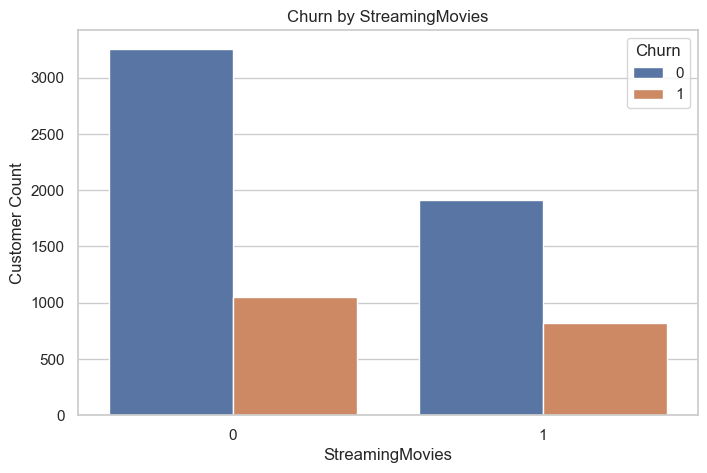

In [28]:
## Visualizing churn distribution across different customer service features

service_cols = [
    'OnlineSecurity', 'TechSupport',
    'StreamingTV', 'StreamingMovies'
]

for col in service_cols:
    sns.countplot(x=col, hue='Churn', data=df)
    plt.title(f"Churn by {col}")
    plt.xlabel(col)
    plt.ylabel("Customer Count")
    plt.legend(title="Churn")
    plt.show()

    ##This visualization shows that customers without essential services like OnlineSecurity and TechSupport are more likely to churn, indicating these services play a key role in customer retention.

##FEATURE ENGINEERING

In [29]:
##You’re converting a continuous variable (tenure) into meaningful customer segments.
def tenure_group(tenure):
    if tenure <= 12:
        return "0-12"
    elif tenure <= 24:
        return "13-24"
    elif tenure <= 48:
        return "25-48"
    else:
        return "49+"

df['TenureGroup'] = df['tenure'].apply(tenure_group)

df[['tenure', 'TenureGroup']].head(10)

##This step groups customers into tenure-based segments to better analyze churn behavior across different customer lifecycle stages.

,tenure,TenureGroup
0,1,0-12
1,34,25-48
2,2,0-12
3,45,25-48
4,2,0-12
5,8,0-12
6,22,13-24
7,10,0-12
8,28,25-48
9,62,49+


In [30]:
pd.crosstab(df['TenureGroup'], df['Churn'], normalize='index')

##This cross-tabulation shows that churn rate decreases significantly as customer tenure increases, confirming tenure as a strong predictor of customer retention.

Churn,0,1
TenureGroup,,
0-12,0.525618,0.474382
13-24,0.712891,0.287109
25-48,0.796110,0.203890
49+,0.904868,0.095132


In [31]:
df['MonthlyChargeGroup'] = pd.qcut(
    df['MonthlyCharges'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

df[['MonthlyCharges', 'MonthlyChargeGroup']].head(10)

##This step uses quantile-based binning to divide customers into balanced pricing tiers, enabling clearer analysis of churn behavior across low, medium, and high monthly charge segments.

,MonthlyCharges,MonthlyChargeGroup
0,29.85,Low
1,56.95,Medium
2,53.85,Medium
3,42.30,Low
4,70.70,Medium
5,99.65,High
6,89.10,High
7,29.75,Low
8,104.80,High
9,56.15,Medium


In [32]:
pd.crosstab(df['MonthlyChargeGroup'], df['Churn'], normalize='index')

##The cross-tabulation reveals that churn rate increases across pricing tiers, with high-charge customers exhibiting the highest probability of churn.

Churn,0,1
MonthlyChargeGroup,,
Low,0.841344,0.158656
Medium,0.703198,0.296802
High,0.659139,0.340861


In [1]:
service_cols = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

##This list groups all service-related binary features to enable structured analysis, visualization, and potential feature engineering based on customer service usage.

In [34]:
df['ServiceCount'] = df[service_cols].sum(axis=1)

df[['ServiceCount']].head(10)

##This step creates a new engagement feature representing the total number of subscribed services per customer, helping capture overall service usage intensity.

,ServiceCount
0,1
1,2
2,2
3,3
4,0
5,3
6,2
7,1
8,4
9,2


In [35]:
pd.crosstab(df['ServiceCount'], df['Churn'], normalize='index')

##The cross-tabulation shows that churn probability decreases steadily as the number of subscribed services increases, indicating strong customer engagement reduces churn risk.

Churn,0,1
ServiceCount,,
0,0.785940,0.214060
1,0.542443,0.457557
2,0.641820,0.358180
3,0.726297,0.273703
4,0.776995,0.223005
5,0.875657,0.124343
6,0.947183,0.052817


In [36]:
service_cols = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

##This list groups all service-related binary features to enable structured analysis, aggregation, and modeling of customer engagement behavior.

In [37]:
#“After feature engineering, I removed redundant raw columns whose information was already captured by engineered features to reduce noise and improve model generalization.”
cols_to_drop = service_cols + ['tenure', 'MonthlyCharges']

df.drop(columns=cols_to_drop, inplace=True)

df.head()

##This step removes raw features whose information has already been captured through engineered features, reducing redundancy and potentially improving model generalization.

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn,TenureGroup,MonthlyChargeGroup,ServiceCount
0,0,0,1,0,0,No phone service,DSL,Month-to-month,1,Electronic check,29.85,0,0-12,Low,1
1,1,0,0,0,1,No,DSL,One year,0,Mailed check,1889.50,0,25-48,Medium,2
2,1,0,0,0,1,No,DSL,Month-to-month,1,Mailed check,108.15,1,0-12,Medium,2
3,1,0,0,0,0,No phone service,DSL,One year,0,Bank transfer (automatic),1840.75,0,25-48,Low,3
4,0,0,0,0,1,No,Fiber optic,Month-to-month,1,Electronic check,151.65,1,0-12,Medium,0


In [38]:
df.columns

##This step confirms the final structure of the dataset after feature selection, ensuring only relevant engineered features remain before model training.

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn', 'TenureGroup', 'MonthlyChargeGroup', 'ServiceCount'], dtype='object')

In [39]:
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols

##This step automatically identifies all remaining categorical features that require encoding before model training.

Index(['MultipleLines', 'InternetService', 'Contract', 'PaymentMethod', 'TenureGroup'], dtype='object')

In [40]:
df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

df_encoded.head()

##This step converts all categorical features into one-hot encoded numeric variables, creating a fully machine-learning-ready dataset.

,gender,SeniorCitizen,Partner,Dependents,PhoneService,PaperlessBilling,TotalCharges,Churn,MonthlyChargeGroup,ServiceCount,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_13-24,TenureGroup_25-48,TenureGroup_49+
0,0,0,1,0,0,1,29.85,0,Low,1,True,False,False,False,False,False,False,True,False,False,False,False
1,1,0,0,0,1,0,1889.50,0,Medium,2,False,False,False,False,True,False,False,False,True,False,True,False
2,1,0,0,0,1,1,108.15,1,Medium,2,False,False,False,False,False,False,False,False,True,False,False,False
3,1,0,0,0,0,0,1840.75,0,Low,3,True,False,False,False,True,False,False,False,False,False,True,False
4,0,0,0,0,1,1,151.65,1,Medium,0,False,False,True,False,False,False,False,True,False,False,False,False


In [41]:
# convert boolean columns to int
bool_cols = df_encoded.select_dtypes(include='bool').columns
bool_cols

##This step identifies boolean columns created during one-hot encoding so they can be converted into numeric format for consistent model input.

Index(['MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'TenureGroup_13-24', 'TenureGroup_25-48', 'TenureGroup_49+'], dtype='object')

In [42]:
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

df_encoded[bool_cols].head()

##This step converts all boolean dummy variables into integer format, ensuring a fully numeric and model-compatible dataset.

,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_13-24,TenureGroup_25-48,TenureGroup_49+
0,1,0,0,0,0,0,0,1,0,0,0,0
1,0,0,0,0,1,0,0,0,1,0,1,0
2,0,0,0,0,0,0,0,0,1,0,0,0
3,1,0,0,0,1,0,0,0,0,0,1,0
4,0,0,1,0,0,0,0,1,0,0,0,0


In [43]:
df_encoded = pd.get_dummies(
    df_encoded,
    columns=['MonthlyChargeGroup'],
    drop_first=True
)

##This step converts the MonthlyChargeGroup categorical feature into one-hot encoded numeric variables to prevent unintended ordinal bias in modeling.

In [44]:
df_encoded.select_dtypes(include=['object']).columns

##This step verifies that no object-type columns remain in the dataset, ensuring it is fully numeric and ready for machine learning models.

Index([], dtype='object')

In [45]:
df_encoded.shape

##This step verifies the final dataset dimensions after preprocessing and feature engineering, confirming readiness for model training.

(7043, 23)

In [46]:
'Churn' in df_encoded.columns

True

In [47]:
df_encoded.to_csv(
    "../data/processed/telco_churn_model_ready.csv",
    index=False
)

print("✅ Model-ready dataset saved")

##This step saves the fully processed and encoded dataset, ensuring reproducibility and separating preprocessing from model training for a clean ML workflow.

✅ Model-ready dataset saved


## Model Building

In [48]:
import pandas as pd
import numpy as np

# load final dataset
df = pd.read_csv("../data/processed/telco_churn_model_ready.csv")

df.head()

##This step loads the finalized, fully preprocessed dataset into a fresh modeling environment, ensuring clean separation between preprocessing and model training stages.

,gender,SeniorCitizen,Partner,Dependents,PhoneService,PaperlessBilling,TotalCharges,Churn,ServiceCount,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_13-24,TenureGroup_25-48,TenureGroup_49+,MonthlyChargeGroup_Medium,MonthlyChargeGroup_High
0,0,0,1,0,0,1,29.85,0,1,1,0,0,0,0,0,0,1,0,0,0,0,False,False
1,1,0,0,0,1,0,1889.50,0,2,0,0,0,0,1,0,0,0,1,0,1,0,True,False
2,1,0,0,0,1,1,108.15,1,2,0,0,0,0,0,0,0,0,1,0,0,0,True,False
3,1,0,0,0,0,0,1840.75,0,3,1,0,0,0,1,0,0,0,0,0,1,0,False,False
4,0,0,0,0,1,1,151.65,1,0,0,0,1,0,0,0,0,1,0,0,0,0,True,False


In [49]:
X = df.drop(columns=['Churn'])
y = df['Churn']

print(X.shape, y.shape)

##This step separates the dataset into feature matrix (X) and target variable (y), preparing the data for supervised model training.

(7043, 22) (7043,)


In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

##This step splits the dataset into stratified training and testing sets, preserving class distribution and ensuring unbiased model evaluation.

Train shape: (5634, 22)
Test shape: (1409, 22)


In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# scale features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##This step standardizes feature values using training data statistics to ensure scale-sensitive models like Logistic Regression perform optimally without data leakage.

In [52]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(
    max_iter=3000,
    class_weight='balanced',
    solver='saga'
)

log_reg.fit(X_train_scaled, y_train)

##This step trains a class-balanced Logistic Regression model using scaled training data to predict customer churn while accounting for class imbalance.

LogisticRegression(class_weight='balanced', max_iter=3000, solver='saga')

In [53]:
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

##This step generates both final class predictions and churn probability scores, enabling performance evaluation and business-level risk prioritization

In [54]:
# predictions (use SCALED data)
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

##This evaluation block measures classification performance using precision, recall, F1-score, ROC-AUC, and confusion matrix to assess churn detection effectiveness in an imbalanced dataset.

Accuracy: 0.7317246273953159
Precision: 0.4965753424657534
Recall: 0.7754010695187166
F1 Score: 0.605427974947808
ROC-AUC: 0.834702523960836

Confusion Matrix:
 [[741 294]
 [ 84 290]]


## Model Interpretation and feature Importance

In [55]:
feature_names = X.columns
len(feature_names)

##This step retrieves and counts the feature names used in the model, preparing for interpretation of learned coefficients.

22

In [56]:
coefficients = log_reg.coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

##This step extracts and organizes the learned Logistic Regression coefficients, enabling interpretation of how each feature influences churn probability.

In [57]:
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

coef_df.head(10)

##This step identifies the top features that increase churn risk by sorting logistic regression coefficients in descending order.

,Feature,Coefficient
10,InternetService_Fiber optic,0.514910
15,PaymentMethod_Electronic check,0.225443
5,PaperlessBilling,0.198252
9,MultipleLines_Yes,0.149075
21,MonthlyChargeGroup_High,0.082691
1,SeniorCitizen,0.068308
8,MultipleLines_No phone service,0.060787
16,PaymentMethod_Mailed check,0.032352
0,gender,0.019752
14,PaymentMethod_Credit card (automatic),0.003604


In [58]:
coef_df.tail(10)

##This step identifies the strongest retention-driving features by examining the most negative logistic regression coefficients.

,Feature,Coefficient
4,PhoneService,-0.060787
20,MonthlyChargeGroup_Medium,-0.063552
3,Dependents,-0.103008
6,TotalCharges,-0.277900
17,TenureGroup_13-24,-0.288918
12,Contract_One year,-0.326329
11,InternetService_No,-0.343182
18,TenureGroup_25-48,-0.445408
19,TenureGroup_49+,-0.501995
13,Contract_Two year,-0.771230


In [59]:
# top churn increasing features
top_positive = coef_df.head(10)

# top churn reducing features
top_negative = coef_df.tail(10)

# combine them
top_features = pd.concat([top_positive, top_negative])
top_features

##This step consolidates the strongest churn-increasing and churn-reducing features into a single interpretable table for business insight and model explanation.

,Feature,Coefficient
10,InternetService_Fiber optic,0.514910
15,PaymentMethod_Electronic check,0.225443
5,PaperlessBilling,0.198252
9,MultipleLines_Yes,0.149075
21,MonthlyChargeGroup_High,0.082691
1,SeniorCitizen,0.068308
8,MultipleLines_No phone service,0.060787
16,PaymentMethod_Mailed check,0.032352
0,gender,0.019752
14,PaymentMethod_Credit card (automatic),0.003604


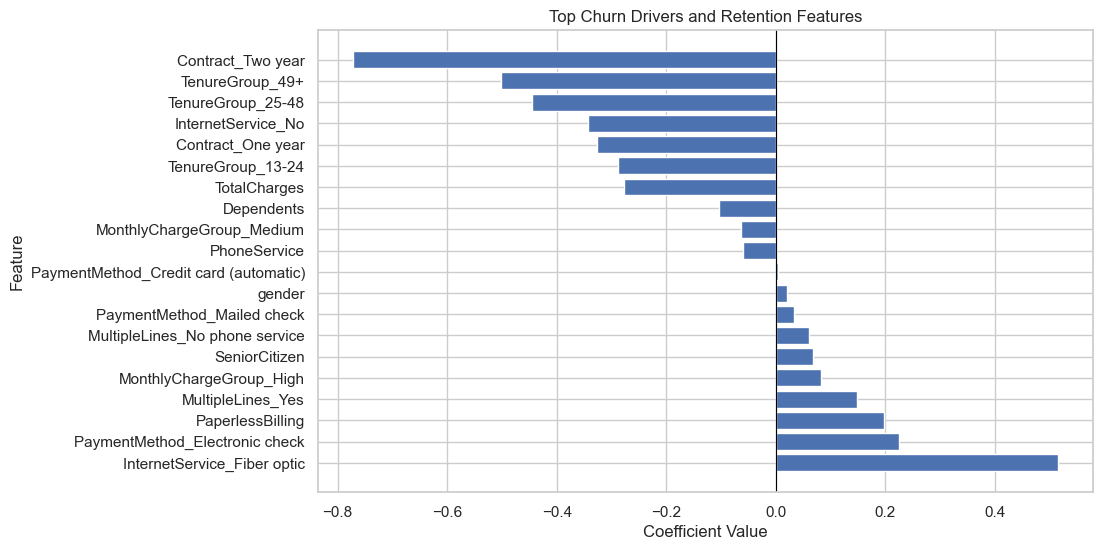

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(
    top_features['Feature'],
    top_features['Coefficient']
)

plt.axvline(0, color='black', linewidth=0.8)
plt.title("Top Churn Drivers and Retention Features")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

### Visualizes top churn-driving and retention-driving features using logistic regression coefficients to understand their impact.


## Most important steps 

In [1]:
def churn_risk(prob):
    if prob >= 0.7:
        return "High"
    elif prob >= 0.4:
        return "Medium"
    else:
        return "Low"

### Categorizes customers into High, Medium, or Low churn risk based on predicted probability.
        

In [62]:
def generate_recommendation(row):
    actions = []

    # High churn risk actions
    if row['ChurnRisk'] == 'High':

        if row.get('Contract_Two year', 0) == 0:
            actions.append("Offer long-term contract discount")

        if row.get('MonthlyChargeGroup_High', 0) == 1:
            actions.append("Provide monthly bill discount")

        if row.get('InternetService_Fiber optic', 0) == 1:
            actions.append("Offer fiber service quality check / loyalty benefit")

        if row['ServiceCount'] <= 1:
            actions.append("Recommend service bundle (TechSupport, Security)")

        if row.get('PaymentMethod_Electronic check', 0) == 1:
            actions.append("Encourage auto-pay with incentive")

    # Medium churn risk actions
    elif row['ChurnRisk'] == 'Medium':
        actions.append("Send personalized retention email")
        actions.append("Suggest value-added services")

    # Low churn risk actions
    else:
        actions.append("Offer loyalty rewards")
        actions.append("Upsell premium services")

    return actions

  ### Creates targeted business actions depending on churn risk category and customer behavior patterns.
  

In [63]:
# create a working copy
results_df = X_test.copy()

# add churn probability
results_df['ChurnProbability'] = y_pred_proba

# add churn risk level
results_df['ChurnRisk'] = results_df['ChurnProbability'].apply(churn_risk)

# generate recommendations
results_df['Recommendations'] = results_df.apply(generate_recommendation, axis=1)

results_df[['ChurnProbability', 'ChurnRisk', 'Recommendations']].head(10)

### Creates final churn predictions with risk categories and recommended actions.


,ChurnProbability,ChurnRisk,Recommendations
437,0.113774,Low,"[Offer loyalty rewards, Upsell premium services]"
2280,0.894370,High,"[Offer long-term contract discount, Provide mo..."
2235,0.145576,Low,"[Offer loyalty rewards, Upsell premium services]"
4460,0.637259,Medium,"[Send personalized retention email, Suggest va..."
3761,0.052266,Low,"[Offer loyalty rewards, Upsell premium services]"
5748,0.730879,High,"[Offer long-term contract discount, Provide mo..."
3568,0.665379,Medium,"[Send personalized retention email, Suggest va..."
2976,0.263707,Low,"[Offer loyalty rewards, Upsell premium services]"
5928,0.019135,Low,"[Offer loyalty rewards, Upsell premium services]"
1639,0.585285,Medium,"[Send personalized retention email, Suggest va..."


## Bussiness Impact and Recommendation Evaluation

In [64]:
# results_df already contains:
# ChurnProbability, ChurnRisk, Recommendations

results_df[['ChurnProbability', 'ChurnRisk']].head()

## Preview of churn probability scores and corresponding risk categories for test customers.


,ChurnProbability,ChurnRisk
437,0.113774,Low
2280,0.894370,High
2235,0.145576,Low
4460,0.637259,Medium
3761,0.052266,Low


In [65]:
risk_distribution = results_df['ChurnRisk'].value_counts()
risk_distribution

### Calculates the distribution of customers across churn risk categories.


ChurnRisk
Low       715
High      350
Medium    344
Name: count, dtype: int64

In [66]:
retention_rates = {
    'High': 0.40,
    'Medium': 0.25,
    'Low': 0.10
}

### Assumed retention effectiveness percentages for High, Medium, and Low risk customers.


In [67]:
impact_df = risk_distribution.reset_index()
impact_df.columns = ['ChurnRisk', 'CustomerCount']

impact_df['RetentionRate'] = impact_df['ChurnRisk'].map(retention_rates)

impact_df['ExpectedRetainedCustomers'] = (
    impact_df['CustomerCount'] * impact_df['RetentionRate']
).astype(int)

impact_df

### Computes expected retention impact by combining customer risk distribution with predefined retention success rates.


,ChurnRisk,CustomerCount,RetentionRate,ExpectedRetainedCustomers
0,Low,715,0.10,71
1,High,350,0.40,140
2,Medium,344,0.25,86


In [68]:
total_customers = impact_df['CustomerCount'].sum()
total_retained = impact_df['ExpectedRetainedCustomers'].sum()

churn_reduction_percent = (total_retained / total_customers) * 100

total_customers, total_retained, churn_reduction_percent

### Summarizes projected business impact by calculating total retained customers and estimated churn reduction percentage.


(np.int64(1409), np.int64(297), np.float64(21.078779276082326))

In [69]:
import os

os.makedirs("../models", exist_ok=True)

## Creates a models directory to store trained models for reuse and deployment.


In [70]:
import joblib

# save model
joblib.dump(log_reg, "../models/churn_model.pkl")

# save scaler
joblib.dump(scaler, "../models/scaler.pkl")

print("✅ Model and scaler saved")

## Saves the trained model and scaler for future use and deployment.


✅ Model and scaler saved
